In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn import linear_model
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
#read in training data
train_data = pd.read_csv("train_data.csv", delimiter = ";")

df = pd.DataFrame(train_data)
y_split = df["wb_overall_mean"]


#extract relevant features from training data
train_data = train_data[["rel_1","rel_2","rel_3","rel_4","rel_5",
                         "rel_6","rel_7","rel_8","rel_9","cnorm_1",
                         "cnorm_2","age","gender","ethnicity","ses","denomination","education"]]
#encode dummy variables of categorical data
train_data_dummies = pd.get_dummies(train_data)

#split training data to create validation data
x_train, x_test, y_train, y_test = train_test_split(train_data_dummies, y_split, test_size = 0.2, random_state = 42)


In [ ]:
train_data_dummies

Progress log: Read up on the data (conceptual analysis), read in the data into a jupyter notebook and fit a normal linear regression line. The regression takes the responses from the rel_ responses and compares it to the overall well-being score. Maybe what would be good to do is compare the coefficients to the other mean scores instead of just the overall. Maybe it would be good to run a correlation test. Regression coefficients:  [0.204401,-0.06756281,0.04235165,0.05646504,0.03557858,0.01394905,-0.06650978,-0.0040522,0.05508881]

In [ ]:
#Create random forest model and fit to training data
rf_model = RandomForestRegressor(bootstrap=True)

rf_model.fit(x_train, y_train)

rf_model.feature_importances_

#Use to predict training data
y_pred = rf_model.predict(x_train)

In [ ]:
print(rf_model.predict(x_train))

[3.54509804 3.45879085 3.52199346 ... 3.54101307 3.75150327 3.94522876]


In [76]:
def print_prediction(training, prediction):
    #Create the figure and axis
    f, ax = plt.subplots(1, 1, figsize=(6, 6))

    #Scatter plot of true vs predicted values
    ax.scatter(training, prediction, color="maroon", s=2, label="Predictions")

    #Get limits for the diagonal reference line
    min_val = min(np.min(training), np.min(prediction))
    max_val = max(np.max(training), np.max(prediction))

    #Plot the black dashed diagonal line
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1, label="Ideal Fit")

    #Set labels
    ax.set_xlabel("Religion Predicting Wellbeing-Target")
    ax.set_ylabel("Model Prediction")

    #Remove top and right spines
    sns.despine(ax=ax)

    #Add legend
    ax.legend()

    #Show plot
    plt.show()


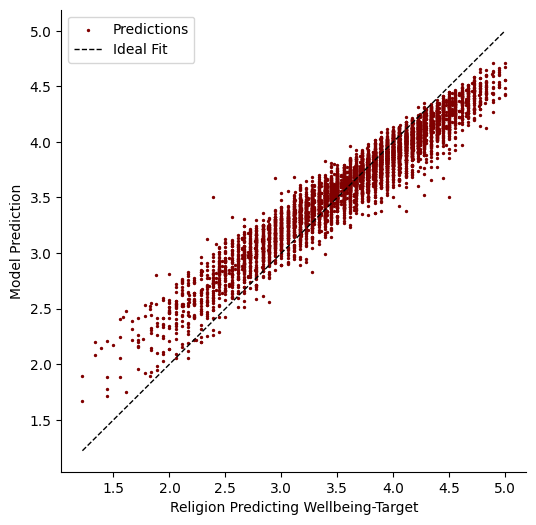

In [74]:
print_prediction(y_train, y_pred)

In [73]:
train_mse = mean_squared_error(y_train, y_pred)
train_mae = mean_absolute_error(y_train, y_pred)
print("Training data prediction. MSE: ", train_mse, " MAE: ",train_mae)

Training data prediction. MSE:  0.042268874832318976  MAE:  0.1603686305692186


In [ ]:
y_pred_test = rf_model.predict(x_test)

print(y_pred_test)


[3.83251634 3.36705882 3.7545098  ... 3.58748366 3.6551634  3.97372549]


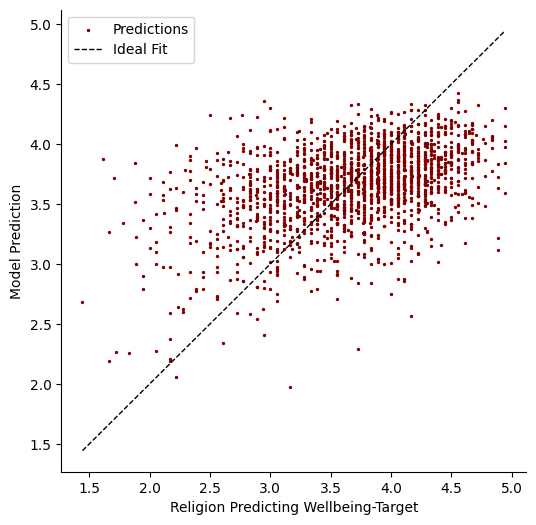

In [ ]:
print_prediction(y_test, y_pred_test)

In [ ]:
test_mse = mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
print("Test data prediction. MSE: ", test_mse, " MAE: ",test_mae)

MSE:  0.29816307004465914  MAE:  0.4309804152493306


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53],
 [Text(0, 0, 'rel_1'),
  Text(1, 0, 'rel_2'),
  Text(2, 0, 'rel_3'),
  Text(3, 0, 'rel_4'),
  Text(4, 0, 'rel_5'),
  Text(5, 0, 'rel_6'),
  Text(6, 0, 'rel_7'),
  Text(7, 0, 'rel_8'),
  Text(8, 0, 'rel_9'),
  Text(9, 0, 'cnorm_1'),
  Text(10, 0, 'cnorm_2'),
  Text(11, 0, 'age'),
  Text(12, 0, 'ses'),
  Text(13, 0, 'education'),
  Text(14, 0, 'gender_man'),
  Text(15, 0, 'gender_other'),
  Text(16, 0, 'gender_woman'),
  Text(17, 0, 'ethnicity_African'),
  Text(18, 0, 'ethnicity_Armenian'),
  Text(19, 0, 'ethnicity_Asian'),
  Text(20, 0, 'ethnicity_Caucasian/European'),
  Text(21, 0, 'ethnicity_Chinese'),
  Text(22, 0, 'ethnicity_East Asian'),
  Text(23, 0, 'ethnicity_I would ra

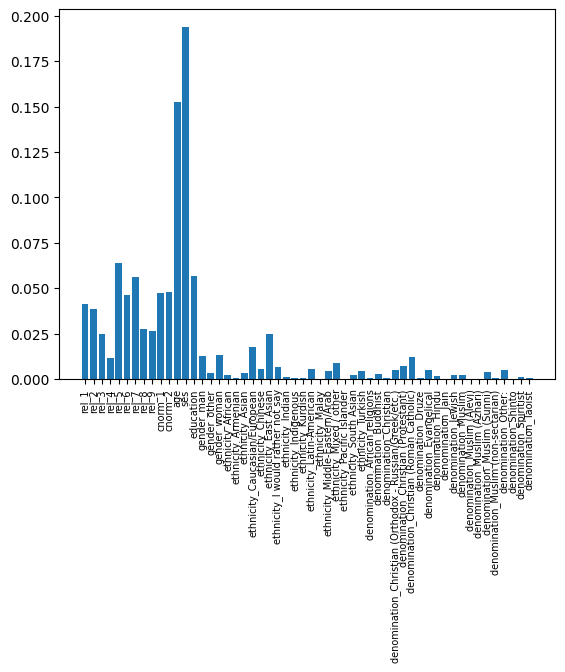

In [ ]:
varnames = list(x_train.columns)
plt.bar(varnames, rf_model.feature_importances_)
plt.xticks(fontsize = 7, rotation = 90)

Provide evaluation here

Possible ways to improve the model:
Use parameters of RandomForest 
Tune hyperparameters of RandomForest
Remove less important/informative features from model and rerun regression

